# Instituto Tecnológico de Costa Rica

Autores: Alexandra Alfaro Elizondo, Francela Arias Vargas, Kendall Madrigal Campos

#  Bloque Latidos por minuto/Prueba Ecostress

El propósito es verificar la calidad estadística de los datos, detectar posibles valores anómalos y comprobar si la distribución del conjunto es normal, con el fin de preparar la señal para etapas posteriores de filtrado y transmisión en el Sistema RF.

In [35]:
# Celda 1: paquetes y módulos 
import pandas as pd
from pandas import ExcelWriter, ExcelFile
import numpy as np
import matplotlib.pyplot as plt

In [36]:
#  Celda 2: Utilidades estadísticas y configuración del entorno
from pathlib import Path
from dataclasses import dataclass # Para crear estructuras de datos simples
from typing import Tuple, List, Optional

# importa las funciones necesarias
from scipy.stats import anderson, t # Pruebas estadísticas AD y t de Student

# Configuración visual mínima de gráficos
plt.rcParams["figure.figsize"] = (8, 4.5) #define tamaño base
plt.rcParams["axes.grid"] = True #activa grid

# Directorio de salida para las figuras
#para mantener el orden según lo solicitado
OUT_DIR = Path("Documentacion/Avance 1/figures") #evita que las figuras se mezclen con código u otros avances
OUT_DIR.mkdir(parents=True, exist_ok=True)

#Estructura de datos para resultados de la prueba AD
@dataclass # agrupa los resultados de la prueba de Anderson–Darling
class ADResult: # mantiene toda la info del test agrupada en un solo objeto
    statistic: float #valor A^2
    crit_values: np.ndarray #valores críticos para distintos niveles de significancia
    sig_levels: np.ndarray #niveles  de significancia: 1%, 2.5%, 5%, 10%, 15%
    decision_alpha_5: bool   # true si no se rechaza la normalidad a α=0.05

# ejecuta la prueba de Anderson–Darling para verificar la normalidad
# de un conjunto de datos numéricos
def anderson_normal_test(x: np.ndarray, alpha: float = 0.05) -> ADResult:
    res = anderson(x, dist='norm') # ejecuta prueba A–D sobre los datos
    # En SciPy no viene p-value directo, comparamos contra el crítico más cercano a alpha
    idx = (np.abs(res.significance_level/100 - alpha)).argmin()
    crit = res.critical_values[idx]
    decision = res.statistic < crit  # true si los datos son compatibles con normalidad
    return ADResult(res.statistic, res.critical_values, res.significance_level, decision)

def basic_stats(x: np.ndarray) -> dict: #calcula los principales estadísticos descriptivos de un vector x
    return {
        "n": x.size, #tamaño muestral 
        "mean": float(np.mean(x)), #media
        "std": float(np.std(x, ddof=1)), #desv. estándar muestral
        "min": float(np.min(x)), #valor mínimo
        "q1": float(np.quantile(x, 0.25)), #primer cuartil
        "median": float(np.median(x)), #mediana
        "q3": float(np.quantile(x, 0.75)), #tercer cuartil
        "max": float(np.max(x)), #valor máx
    }

In [37]:
# carga del conjutno de datos para convertirlo en un formato numérico maneajable (numpy)
DATA_PATH = Path("Dataset.xlsx")  #objeto PATH que apunta al archivo excel
COLUMN    = "BPM"                 
                   
df = pd.read_excel(DATA_PATH) #lectura del excel

x = df[COLUMN].dropna().to_numpy(dtype=float) #conversión de datos

print(f"Archivo: {DATA_PATH.resolve()}") #muestra la ruta

Archivo: C:\Users\Lexie\OneDrive - Estudiantes ITCR\TEC\II Semestre -2025\Taller de Comu\Proyecto\Grupo2_TCE\Jupyter\Dataset.xlsx


In [38]:
#analisis estadístico inicial antes de aplicar filtros
stats = basic_stats(x) #funcion definida en la celda 1, se les carga el vector x
stats #calcula y devuelve el diccionario
print("Estadística descriptiva:") #presentación de resultados numéricos
for k in ["n","mean","std","min","q1","median","q3","max"]:
    print(f"{k:>7}: {stats[k]:.3f}" if k!="n" else f"{k:>7}: {stats[k]}")
#prueba AD
alpha = 0.05 # nivel de significancia (5%) equivalente a un 95% de confianza
ad = anderson_normal_test(x, alpha=alpha)  # ejecuta la prueba sobre el vector de datos
# resultados principales del test
print(f"\n Anderson–Darling (normal):")
print(f"  Estadístico A^2: {ad.statistic:.4f}")
#tabla de niveles de significancia y valores críticos
for sl, cv in zip(ad.sig_levels, ad.crit_values):
    print(f"  Nivel {sl:>5.1f}%  →  Crítico {cv:.4f}")

if ad.decision_alpha_5:
    print(f"\n Decisión (α={alpha}): NO se rechaza H0. Los datos provienen de una distribución normal.")
else:
    print(f"\n Decisión (α={alpha}): Se rechaza H0 (NO normal).")
    


Estadística descriptiva:
      n: 127
   mean: 129.155
    std: 19.727
    min: 90.436
     q1: 114.678
 median: 128.714
     q3: 143.593
    max: 164.849

 Anderson–Darling (normal):
  Estadístico A^2: 0.5773
  Nivel  15.0%  →  Crítico 0.5590
  Nivel  10.0%  →  Crítico 0.6370
  Nivel   5.0%  →  Crítico 0.7640
  Nivel   2.5%  →  Crítico 0.8910
  Nivel   1.0%  →  Crítico 1.0600

 Decisión (α=0.05): NO se rechaza H0. Los datos provienen de una distribución normal.


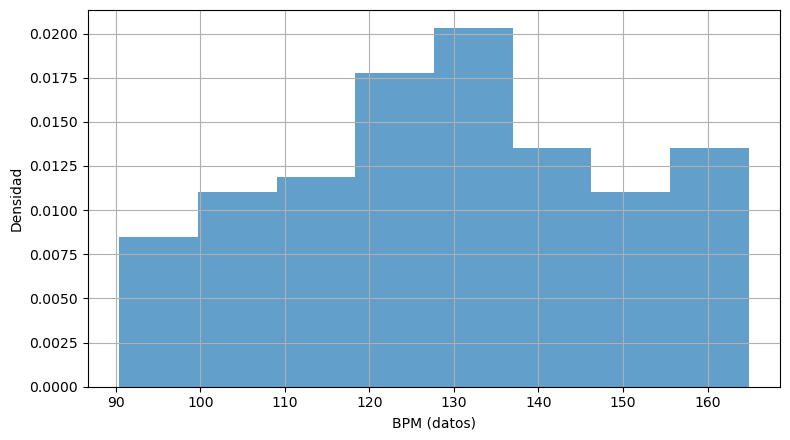

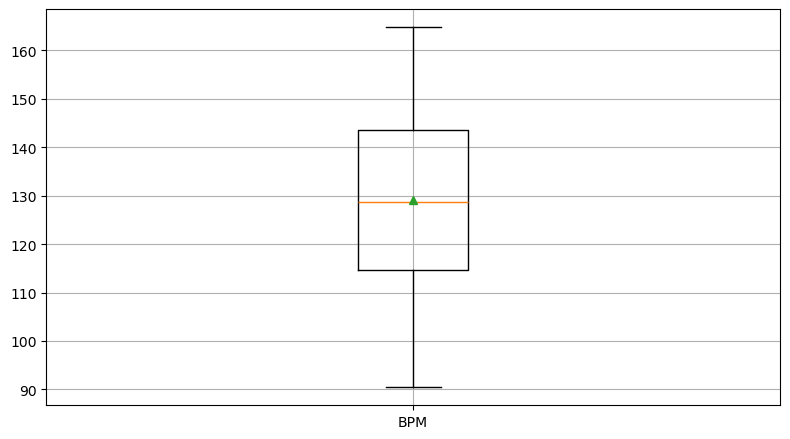

Figuras guardadas en:
 - Documentacion\Avance 1\figures\hist_bpm.png
 - Documentacion\Avance 1\figures\box_bpm.png


In [39]:
#visualización de la distribución de datos

#histograma
fig, ax = plt.subplots()
ax.hist(x, bins="auto", density=True, alpha=0.7)
ax.set_xlabel("BPM (datos)")  # etiqueta del eje X
ax.set_ylabel("Densidad") # etiqueta del eje Y
fig.tight_layout()
hist_path = OUT_DIR / "hist_bpm.png"
fig.savefig(hist_path, dpi=600) # exporta en formato PNG a 600 dpi
plt.show()


fig, ax = plt.subplots()
ax.boxplot(x, vert=True, showmeans=True)
ax.set_xticks([1]); ax.set_xticklabels([COLUMN])
fig.tight_layout()
box_path = OUT_DIR / "box_bpm.png"
fig.savefig(box_path, dpi=600)
plt.show()

print(f"Figuras guardadas en:\n - {hist_path}\n - {box_path}")


In [44]:
#celda para detectar datos atípicos (test de Grubbs)
from math import sqrt
from scipy.stats import t #usada para calcular el valor crítico
#detectar si un valor extremo se considera outlier
def grubbs_critical_value(n: int, alpha: float = 0.05) -> float: #calcula el valor crítico que marca el límite entre "valor normal y valor atípico"
    dof = n - 2 #grados de libertad
    t_alpha = t.ppf(1 - alpha/(2*n), dof) #ajuste bilateral
    return ((n - 1) / sqrt(n)) * sqrt((t_alpha**2) / (dof + t_alpha**2))   # Devuelve Gcrit, umbral de decisión que depende de n y alpha

def grubbs_test_once(x: np.ndarray, alpha: float = 0.05) -> Tuple[bool, int, float]:
    mu, s = np.mean(x), np.std(x, ddof=1)
    diffs = np.abs(x - mu)
    idx = int(np.argmax(diffs))
    G = diffs[idx] / s
    return (G > grubbs_critical_value(x.size, alpha)), idx, G

#ejecuta varias veces el test para aplicar grubs al conjunto completo de datos
def grubbs_iterative(x: np.ndarray, alpha: float = 0.05, max_iters: int = 10):
    x_work = x.copy() # copia del conjunto original (para no modificarlo directamente)
    removed = []  # lista donde se almacenan los atípicos detectados
    for _ in range(max_iters):   # itera hasta alcanzar el límite definido
        ok, idx, G = grubbs_test_once(x_work, alpha=alpha)
        if not ok:   # si no hay más atípicos, detiene el bucle
            break
        removed.append((idx, x_work[idx], G))  # guarda el índice, valor y estadístico G
        x_work = np.delete(x_work, idx)  # elimina el dato atípico del vector
    return x_work, removed # retorna los datos limpios y los removidos


x_clean, removed = grubbs_iterative(x, alpha=0.05, max_iters=50)
print(f"Atípicos removidos: {len(removed)}")
for i,(idx,val,G) in enumerate(removed,1):
    print(f"  {i:02d}) idx_local={idx}, valor={val:.3f}, G={G:.3f}")

Atípicos removidos: 0


# Bloque de Preprocesamiento

Este módulo implementa el filtrado de ruido y análisis estadístico previo a la codificación.

In [48]:
import os  # módulo estándar de Python para manejar rutas y directorios
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

Datos:
     Tiempo(s)         BPM
0            0   90.435881
1           10   91.375558
2           20   93.177147
3           30   92.253070
4           40   93.297168
..         ...         ...
122       1220  127.489200
123       1230  125.722564
124       1240  125.176371
125       1250  124.053356
126       1260  123.681245

[127 rows x 2 columns]


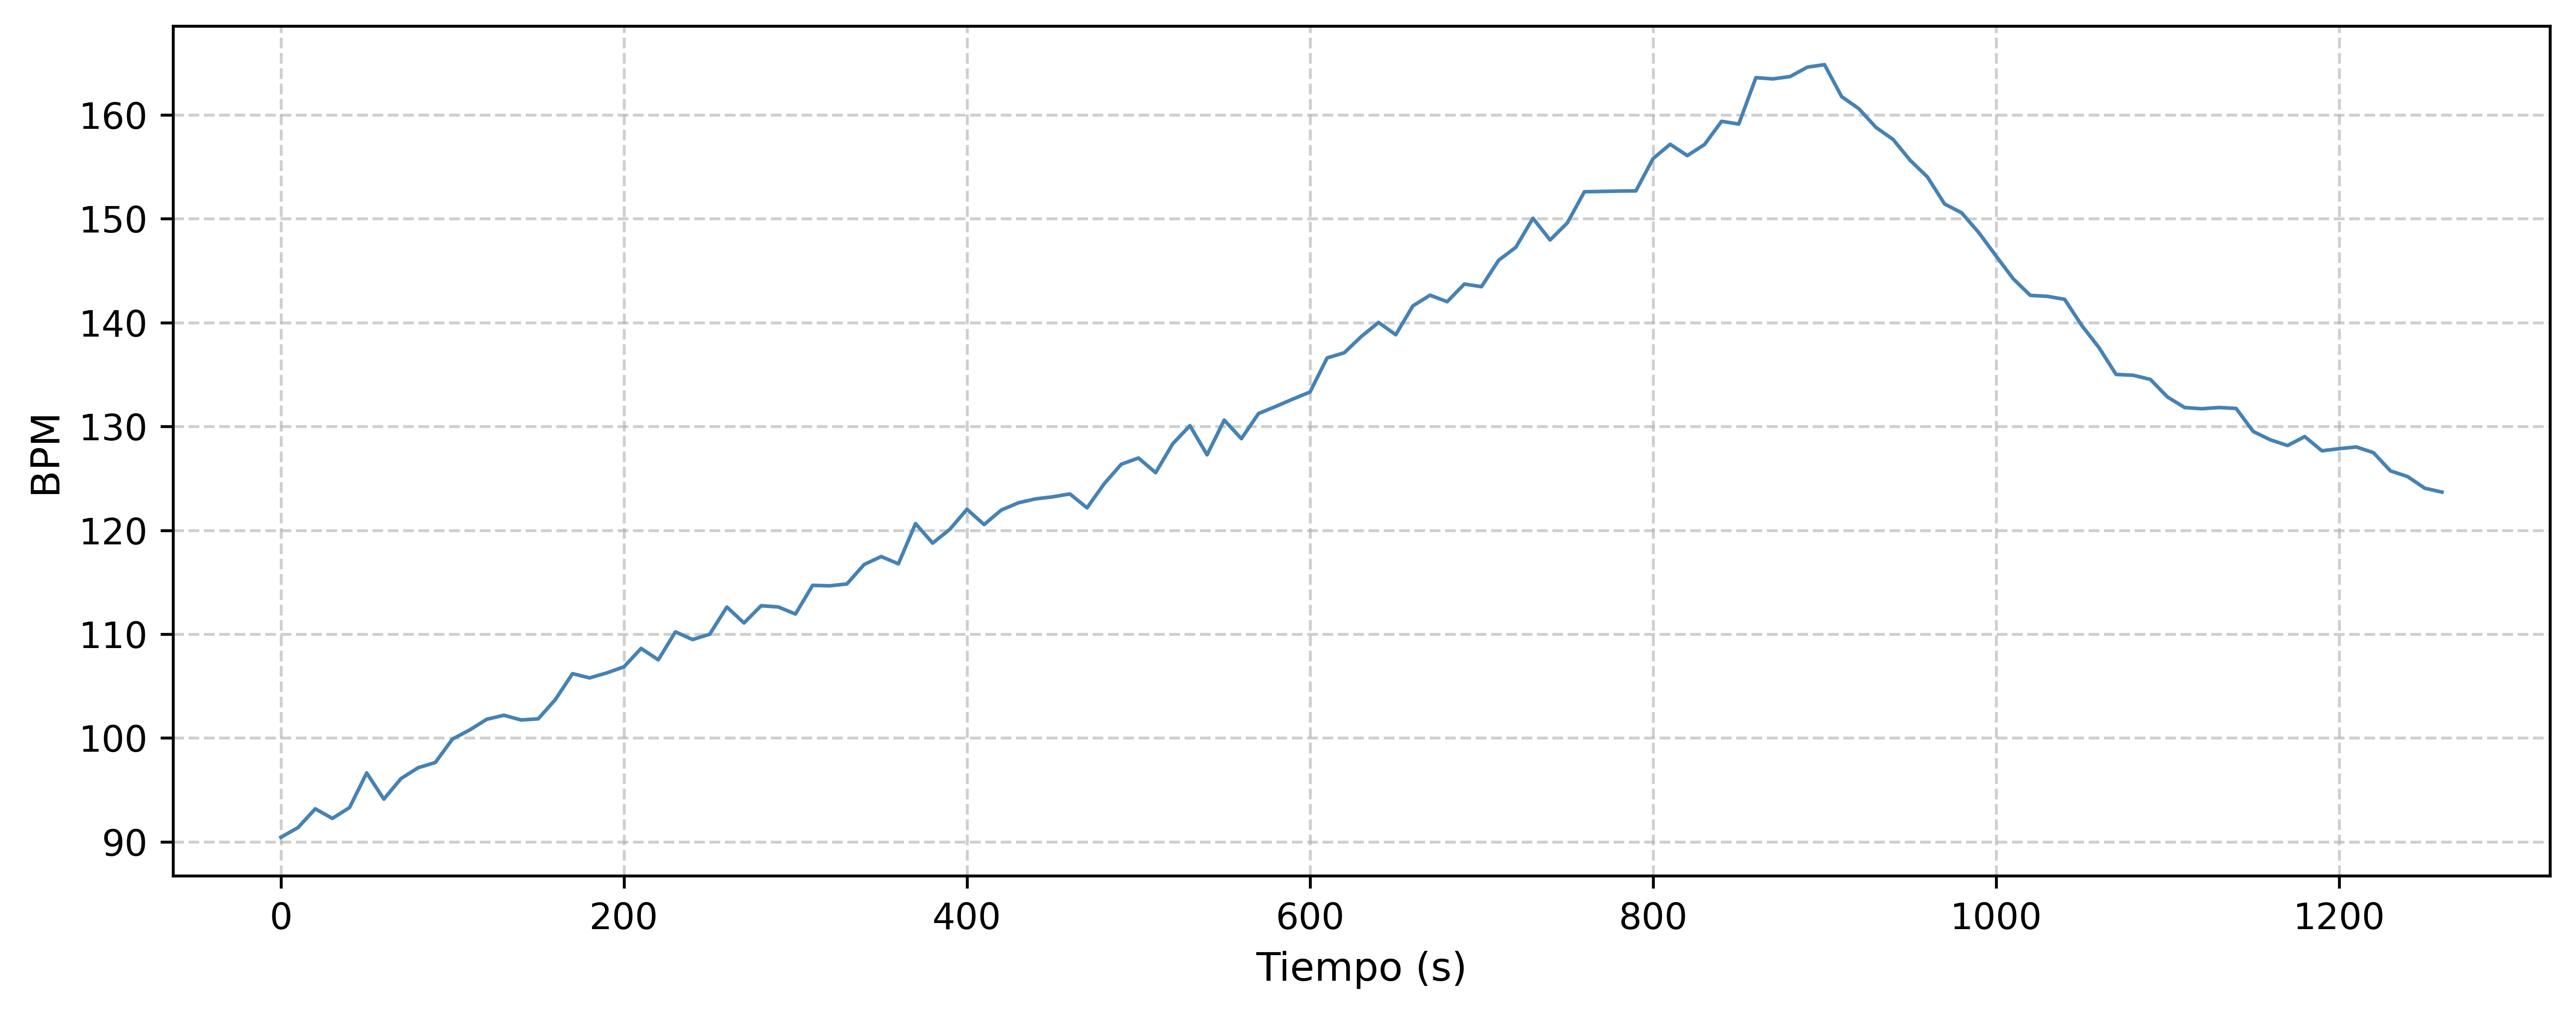

In [51]:
#  directorio de salida para mantener orden
OUT_DIR = Path("Documentacion/Avance 1/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# buscar archivos Excel en el mismo lugar del notebook
archivo_excel = 'Dataset.xlsx'
# cargar el archivo Excel en un DataFrame de pandas
data = pd.read_excel(archivo_excel)

# mostrar los datos completos
print("Datos:")
print(data)
t = data["Tiempo(s)"]
x = data["BPM"]
plt.figure(figsize=(10, 4), dpi=600)
plt.plot(t, x, color='steelblue', linewidth=1)
plt.xlabel("Tiempo (s)", fontsize=11)
plt.ylabel("BPM", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
output_path = OUT_DIR / "senal_original.png" # guardar figura en la ruta solicitada
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()


Info de filtros:
Media móvil: https://www.digikey.com/es/blog/introduction-to-signal-processing-moving-average-filter?msockid=37340f1d666a6d4b130b195167e66c39

Mediana: https://la.mathworks.com/help/images/ref/medfilt2.html

Savitzky–Golay: https://la.mathworks.com/help/signal/ref/sgolayfilt.html

Kalman: https://la.mathworks.com/discovery/kalman-filter.html, https://www.ucm.es/data/cont/media/www/pag-41459/Filtro%20de%20Kalman.pdf

Comparación de filtros: https://riunet.upv.es/server/api/core/bitstreams/f10b624a-bc6b-48f7-868d-dc2af0aa7f3d/content 

In [53]:
import pandas as pd

columnas = [
    "Filtro",
    "Eficacia de filtrado",
    "Preservación de información",
    "Tiempo de computación",
    "Complejidad de implementación",
    "Uso o aplicación recomendada"
]   
# Datos completos de la tabla informativa
data = [
    [
        "Media móvil",
        "Media",
        "Media",
        "Bajo",
        "Muy baja",
        "Adecuado para suavizar ruido blanco en señales estables o con poca variabilidad. "
        "Ofrece una respuesta simple, aunque puede suavizar excesivamente los picos o transiciones rápidas."
    ],
    [
        "Mediana",
        "Alta",
        "Alta",
        "Bajo",
        "Baja",
        "Ideal para eliminar ruido impulsivo o picos aislados sin deformar la señal original. "
        "Muy utilizada en series temporales con valores atípicos."
    ],
     [
        "Savitzky–Golay",
        "Alta",
        "Muy alta",
        "Medio",
        "Media",
        "Suaviza la señal preservando su forma y tendencias principales. "
        "Es apropiado cuando se requiere mantener la morfología para análisis posteriores, "
        "como derivadas o picos característicos."
    ],

    [
        "Kalman",
        "Muy alta",
        "Alta",
        "Regular",
        "Alta",
        "Adecuado para señales dinámicas o con ruido correlacionado. "
        "Permite una estimación óptima cuando se dispone de un modelo del sistema "
        "o conocimiento previo de la dinámica de la señal."
    ],
]
# Crear DataFrame
tradeoff_info = pd.DataFrame(data, columns=columnas)

# Mostrar la tabla
print("Matriz trade-off informativa")
display(tradeoff_info)

Matriz trade-off informativa


,Filtro,Eficacia de filtrado,Preservación de información,Tiempo de computación,Complejidad de implementación,Uso o aplicación recomendada
0,Media móvil,Media,Media,Bajo,Muy baja,"Adecuado para suavizar ruido blanco en señales estables o con poca variabilidad. Ofrece una respuesta simple, aunque puede suavizar excesivamente los picos o transiciones rápidas."
1,Mediana,Alta,Alta,Bajo,Baja,Ideal para eliminar ruido impulsivo o picos aislados sin deformar la señal original. Muy utilizada en series temporales con valores atípicos.
2,Savitzky–Golay,Alta,Muy alta,Medio,Media,"Suaviza la señal preservando su forma y tendencias principales. Es apropiado cuando se requiere mantener la morfología para análisis posteriores, como derivadas o picos característicos."
3,Kalman,Muy alta,Alta,Regular,Alta,Adecuado para señales dinámicas o con ruido correlacionado. Permite una estimación óptima cuando se dispone de un modelo del sistema o conocimiento previo de la dinámica de la señal.


Se decide comparar los filtros: Mediana y Savitzky–Golay.

# Filtro mediana
Resultados de tiempo de ejecución:

In [64]:
import time # módulo estándar para medir tiempos de ejecución
from scipy.signal import medfilt  # función de filtro de mediana
kernel_size=5

# función que aplica el filtro y mide el tiempo de ejecución
def medir_tiempo_mediana(x, kernel_size=5):
    inicio = time.perf_counter()
    _ = medfilt(x, kernel_size=kernel_size)
    fin = time.perf_counter()
    return fin - inicio  # tiempo en segundos

# ejecutar 200 veces y almacenar los tiempos
n_ejecuciones = 200
tiempos = np.zeros(n_ejecuciones)

for i in range(n_ejecuciones):
    tiempos[i] = medir_tiempo_mediana(x, kernel_size)

# calcular estadísticas
tiempo_promedio = np.mean(tiempos)
tiempo_std = np.std(tiempos)

print(f" Resultados tiempo de ejecución (Filtro de Mediana):")
print(f"Número de ejecuciones: {n_ejecuciones}")
print(f"Tamaño de ventana: {kernel_size}")
print(f"Tiempo promedio: {tiempo_promedio*1000:.4f} ms")

 Resultados tiempo de ejecución (Filtro de Mediana):
Número de ejecuciones: 200
Tamaño de ventana: 5
Tiempo promedio: 0.0941 ms


In [58]:
#Guardar tiempos en un archivo excel
df_tiempos = pd.DataFrame({"Ejecución": np.arange(1, n_ejecuciones+1), "Tiempo_s": tiempos})
df_tiempos.to_csv("tiempos_mediana.csv", index=False)

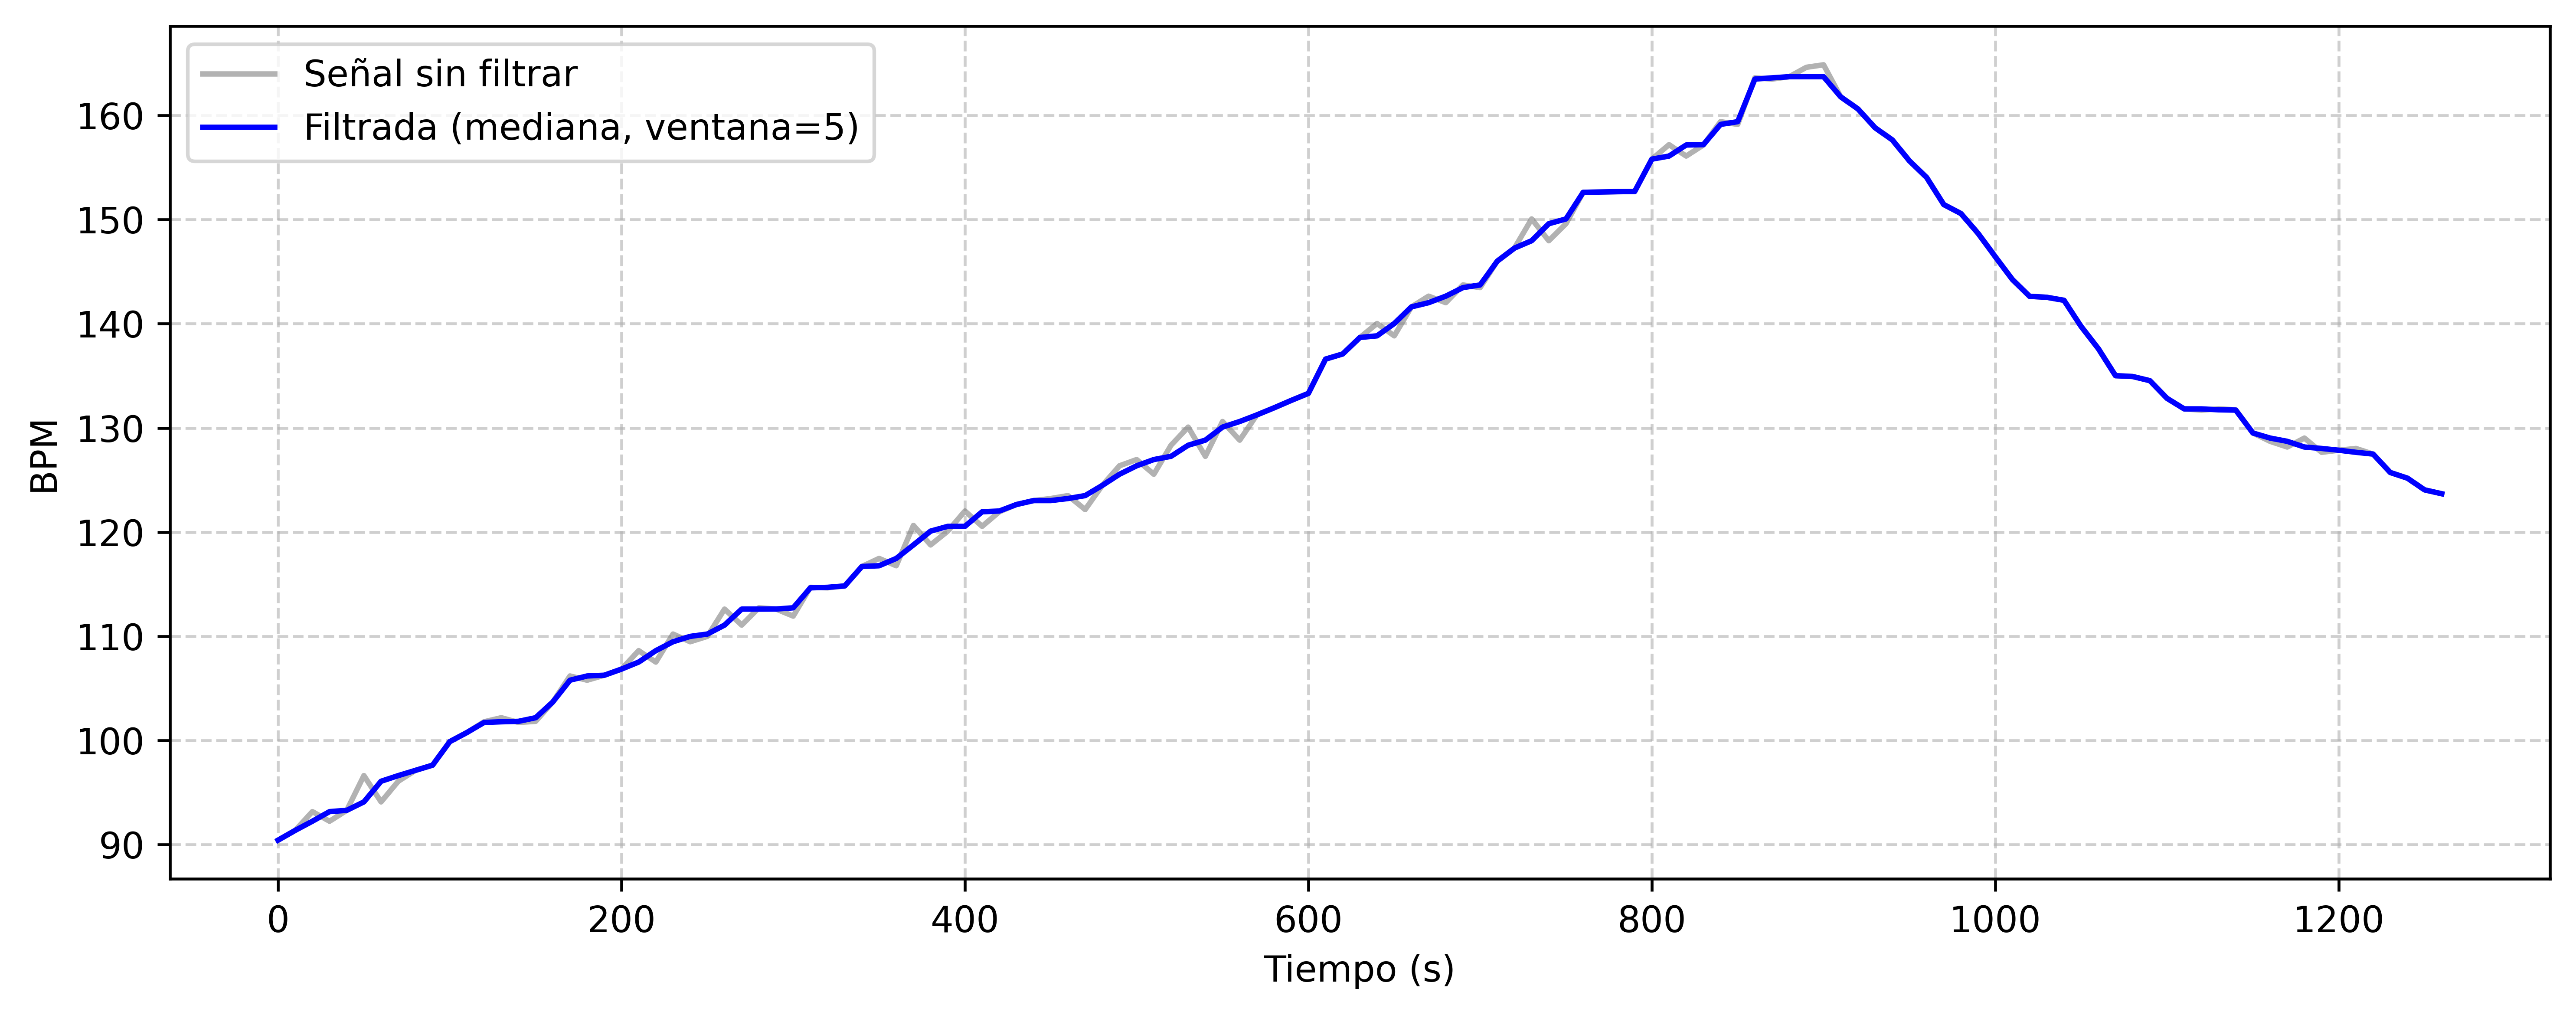

In [61]:
# Guardar los resultados individuales para análisis posterior
window_size = 5
x_median = medfilt(x, window_size)

# Graficar comparación
plt.figure(figsize=(10,4),  dpi=600)
plt.plot(t, x, label='Señal sin filtrar', color='gray', alpha=0.6)
plt.plot(t, x_median, label=f'Filtrada (mediana, ventana={window_size})', color='blue')
plt.xlabel('Tiempo (s)')
plt.ylabel('BPM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
output_path = OUT_DIR / "orig_vs_mediana.png" # guardar figura en la ruta solicitada
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()

# Filtro Savitzky–Golay
Resultados de tiempo de ejecución:

In [63]:
from scipy.signal import savgol_filter  # filtro Savitzky–Golay

# parámetros del filtro
window_length = 5 #debe ser impar y mayor que polyorder
polyorder = 2       # orden del polinomio de ajuste (controla y preserva la forma de la señal frente al ruido)

# función que aplica el filtro y mide el tiempo de ejecución 
def medir_tiempo_savgol(x, window_length=5, polyorder=2):
    inicio = time.perf_counter()
    _ = savgol_filter(x, window_length=window_length, polyorder=polyorder)
    fin = time.perf_counter()
    return fin - inicio  # tiempo en segundos

n_ejecuciones = 200
tiempos_savgol = np.zeros(n_ejecuciones)

for i in range(n_ejecuciones):
    tiempos_savgol[i] = medir_tiempo_savgol(x, window_length=window_length, polyorder=polyorder)

# calcular estadísticas
tiempo_promedio_savgol = np.mean(tiempos_savgol)
tiempo_std_savgol = np.std(tiempos_savgol)

# mostrar resultados
print(f" Resultados tiempo de ejecución (Filtro Savitzky–Golay):")
print(f"Número de ejecuciones: {n_ejecuciones}")
print(f"Tamaño de ventana: {window_length}")
print(f"Orden del polinomio: {polyorder}")
print(f"Tiempo promedio: {tiempo_promedio_savgol*1000:.4f} ms") 


# guardar resultados individuales
df_tiempos_savgol = pd.DataFrame({
    "Ejecución": np.arange(1, n_ejecuciones+1),
    "Tiempo_s": tiempos_savgol
})
df_tiempos_savgol.to_csv("tiempos_savgol.csv", index=False)

# aplicar el filtro una vez para graficar
x_savgol = savgol_filter(x, window_length=window_length, polyorder=polyorder)

 Resultados tiempo de ejecución (Filtro Savitzky–Golay):
Número de ejecuciones: 200
Tamaño de ventana: 5
Orden del polinomio: 2
Tiempo promedio: 0.4825 ms


# Selección del filtro

Se evaluaron los filtros Medianay Savitzky–Golay con el fin de determinar cuál ofrece un mejor equilibrio entre eficacia de filtrado, preservación de información y tiempo de ejecución, de acuerdo con los requerimientos del sistema ECOSTRESS.
El filtro de Mediana fue seleccionado como método de preprocesamientopara el sistema ECOSTRESS, ya que presenta:

- Alta eficacia en la eliminación de ruido impulsivo.  
- Bajo costo computacional, aproximadamente seis veces menor que Savitzky–Golay.
  
$$
\frac{0.3162}{0.0590} \approx 5.75
$$

- Simplicidad de implementación, ideal para portar al SoC nRF52832.  


# Almacenamiento de datos filtrados

In [66]:

OUT_DATA = Path("Documentacion/Avance 1/datos_filtrados") # carpeta destino
OUT_DATA.mkdir(parents=True, exist_ok=True)

salida = pd.DataFrame({
    "Tiempo_s": t,
    "Original": x,
    "Filtrado_Mediana": x_median
})

nombre = OUT_DATA / "filtro_mediana_w5.xlsx"

salida.to_excel(nombre, index=False, engine='openpyxl')

# Bloque de codificación tipo Hamming

Aplicar la codificación Hamming (7,4) y (15,11) sobre los datos filtrados del bloque de preprocesamiento para: añadir redundancia de control (bits de paridad), validar que la codificación es correcta y medir el tiempo promedio de ejecución.

# Tipo (7,4)

In [72]:
from pathlib import Path
import pandas as pd
import numpy as np
from time import perf_counter

In [73]:
def h74_encode_nibble(nib:int):
    b3 = (nib >> 3) & 1; b2 = (nib >> 2) & 1; b1 = (nib >> 1) & 1; b0 = (nib >> 0) & 1 #separa los 4 bits del nibble
    c = [0]*7 #lista vacía donde se guardará la palabra hamming
    c[2], c[4], c[5], c[6] = b3, b2, b1, b0 # asignación de posiciones
    c[0] = c[2] ^ c[4] ^ c[6] #cálculo de los bits de paridad
    c[1] = c[2] ^ c[5] ^ c[6]
    c[3] = c[4] ^ c[5] ^ c[6]
    return c #devuelve los bits codificados

def bytes_to_bits_h74(u8_list):
    out=[]
    for b in u8_list:
        hi=(b>>4)&0xF; lo=b&0xF #divide cada byte en dos nibbles
        out += h74_encode_nibble(hi) #aplica el codificador hamming a cada nibble
        out += h74_encode_nibble(lo)
    return np.array(out, dtype=np.uint8) #concatena los resultados

def verificar_h74(bits):
    assert len(bits) % 7 == 0 #verifica que los bloques sean múltiplos de 7
    malos=0  #sumador de bloques malos
    for i in range(0,len(bits),7):
        c=bits[i:i+7] #recorre los bits de 7 en 7 recalcula paridades (síndrome)
        s1=c[0]^c[2]^c[4]^c[6]
        s2=c[1]^c[2]^c[5]^c[6]
        s4=c[3]^c[4]^c[5]^c[6]
        if (s1|s2|s4)!=0: malos+=1
    return (len(bits)//7, malos)

def tiempo_stats_h74(data_bytes, repeticiones=200):
    ts=[]
    for _ in range(repeticiones):
        t0=perf_counter(); _=bytes_to_bits_h74(data_bytes); t1=perf_counter()
        ts.append(t1-t0)
    ts=np.array(ts); return ts.mean()


In [74]:
#entrada de datos
archivo_excel = Path("Documentacion/Avance 1/datos_filtrados/filtro_mediana_w5.xlsx")
columna = "Filtrado_Mediana"

df = pd.read_excel(archivo_excel, engine="openpyxl") 
serie = df[columna] if isinstance(columna, str) else df.iloc[:, columna]
data_u8 = np.clip(np.nan_to_num(serie.to_numpy(), nan=0.0), 0, 255).astype(np.uint8) 

print("Bytes listos:", len(data_u8))


Bytes listos: 127


In [90]:
bits_cod = bytes_to_bits_h74(data_u8)  
bits_cod = np.asarray(bits_cod, dtype=np.uint8).reshape(-1)  # vector columna 0/1
esperados = 14 * len(data_u8)

assert bits_cod.size == esperados, (
    f"Largo inesperado: {bits_cod.size} vs {esperados} (14 bits por byte). "
)
bloques = bits_cod.size // 7                    # 7 bits por bloque (7,4)
total, con_error = verificar_h74(bits_cod)
print(f"- Bytes entrada         : {len(data_u8)}")
print(f"- Bits codificados (7,4): {bits_cod.size} (esperado = {esperados})")
print(f"Bloques válidos: {total-con_error}/{total}")

- Bytes entrada         : 127
- Bits codificados (7,4): 1778 (esperado = 1778)
Bloques válidos: 254/254


In [76]:
# Exportar los bits codificados para el bloque de Modulación en matlab

salida_dir = Path("Matlab")
salida_dir.mkdir(parents=True, exist_ok=True)

ruta_txt = salida_dir / "bits_codificados_h74.txt"
ruta_npy = salida_dir / "bits_codificados_h74.npy"

# Guardar como texto (una columna de 0/1)
np.savetxt(ruta_txt, bits_cod.astype(np.uint8), fmt="%d")
# Guardar también en binario numpy (opcional)
np.save(ruta_npy, bits_cod.astype(np.uint8))


In [78]:
mean_s = tiempo_stats_h74(data_u8, repeticiones=200)

print(f"Archivo: {archivo_excel.name}")
print(f"Tiempo promedio (200): {mean_s*1e3:.4f} ms")


Archivo: filtro_mediana_w5.xlsx
Tiempo promedio (200): 0.7847 ms


# Tipo (15,11)

El código Hamming (15,11) trabaja con bloques de 11 bits a los que se añaden 4 bits de paridad para formar palabras codificadas de 15 bits, capaces de detectar y corregir un error por bloque.

In [80]:
# Utilidades de bits
def bytes_to_bitstream_MSBfirst(u8: np.ndarray) -> np.ndarray: 
    u8 = np.asarray(u8, dtype=np.uint8) #arreglo NumPy de enteros de 8 bits
    out = np.unpackbits(u8, bitorder='big')
    return out.astype(np.uint8)

def chunk11_with_padding(bits: np.ndarray) -> np.ndarray: #Convertir toda la señal (lista de bytes) a una secuencia continua de bits (bitstream)
    """Parte el bitstream en bloques de 11 bits, con padding de ceros al final."""
    n = bits.size # Calcula cuántos bits hay en total
    r = n % 11 # Calcula el residuo al dividir entre 11, es decir, cuántos bits “sobran”
    if r != 0:
        pad = np.zeros(11 - r, dtype=np.uint8) # Crea un arreglo con los ceros necesarios para completar el último bloque.
        bits = np.concatenate([bits, pad])
    return bits.reshape(-1, 11)

In [81]:
# se calculan los bits de paridad y se forman los 15 bits codificados
# Paridades en 1,2,4,8; datos en 3,5,6,7,9–15

def h1511_encode_block(bits11):
    b10,b9,b8,b7,b6,b5,b4,b3,b2,b1,b0 = map(int, bits11) #asignar posiciones
    c = [0]*15 # lista de 15 ceros que contendrá los bits codificados
    # Datos
    c[2], c[4], c[5], c[6], c[8], c[9], c[10], c[11], c[12], c[13], c[14] = \
        b10,b9,b8,b7,b6,b5,b4,b3,b2,b1,b0 
    # cálculo de los bits de paridad
    c[0] = c[2]^c[4]^c[6]^c[8]^c[10]^c[12]^c[14]
    c[1] = c[2]^c[5]^c[6]^c[9]^c[10]^c[13]^c[14]
    c[3] = c[4]^c[5]^c[6]^c[11]^c[12]^c[13]^c[14]
    c[7] = c[8]^c[9]^c[10]^c[11]^c[12]^c[13]^c[14]
    return np.array(c, dtype=np.uint8)

def bitstream_to_h1511(bits: np.ndarray) -> np.ndarray:
    """Codifica bitstream arbitrario en palabras Hamming (15,11)."""
    bloques = chunk11_with_padding(bits)
    codificados = [h1511_encode_block(b) for b in bloques] # llama a la primer función para cada bloque
    return np.concatenate(codificados).astype(np.uint8)

In [82]:
def verificar_h1511(bitstream15):
    """Verifica que cada bloque tenga síndrome (0,0,0,0).""" #recorre todos los bloques de 15 bits y verifica las paridades
    assert bitstream15.size % 15 == 0 #revisa que el tamaño total del arreglo sea múltiplo de 15
    malos = 0 #contador para malos codificados
    for i in range(0, bitstream15.size, 15):
        c = bitstream15[i:i+15] #cálculo de los bits de síndrome
        s1 = c[0]^c[2]^c[4]^c[6]^c[8]^c[10]^c[12]^c[14]
        s2 = c[1]^c[2]^c[5]^c[6]^c[9]^c[10]^c[13]^c[14]
        s4 = c[3]^c[4]^c[5]^c[6]^c[11]^c[12]^c[13]^c[14]
        s8 = c[7]^c[8]^c[9]^c[10]^c[11]^c[12]^c[13]^c[14]
        if (s1|s2|s4|s8)!=0:
            malos += 1
    total = bitstream15.size // 15
    return total, malos


In [84]:
def tiempo_stats_h1511(data_bytes_u8, repeticiones=200):
    """Mide el tiempo promedio de codificación Hamming (15,11)."""
    bits = bytes_to_bitstream_MSBfirst(data_bytes_u8)
    ts=[] #lista vacía donde se guardan los tiempos de cada ejecución
    for _ in range(repeticiones): #proceso de medición repetida
        t0 = perf_counter()
        _ = bitstream_to_h1511(bits)
        t1 = perf_counter()
        ts.append(t1 - t0)
    ts = np.array(ts) 
    return ts.mean()

In [85]:
# lectura de los datos reales
INFILE = Path("Documentacion/Avance 1/datos_filtrados/filtro_mediana_w5.xlsx")
COL = "Filtrado_Mediana"

df = pd.read_excel(INFILE, engine="openpyxl")
serie = df[COL]
data_u8 = np.clip(np.nan_to_num(serie.to_numpy(), nan=0.0), 0, 255).astype(np.uint8)

#Codificación Hamming (15,11)
bits_in   = bytes_to_bitstream_MSBfirst(data_u8)
bits_1511 = bitstream_to_h1511(bits_in)

# verificación
total, con_error = verificar_h1511(bits_1511)


print(f"Archivo: {INFILE.name}")
print(f"Bytes de entrada: {len(data_u8)} | Bits codificados: {len(bits_1511)}")
print(f"Bloques válidos: {total-con_error}/{total}")

Archivo: filtro_mediana_w5.xlsx
Bytes de entrada: 127 | Bits codificados: 1395
Bloques válidos: 93/93


In [87]:
mean_s = tiempo_stats_h1511(data_u8, repeticiones=200)
print(f"Tiempo promedio (200 corridas): {mean_s*1e3:.4f} ms")

Tiempo promedio (200 corridas): 0.5631 ms


In [91]:
try:
    bits_1511
except NameError:
    bits_in = bytes_to_bitstream_MSBfirst(data_u8)
    bits_1511 = bitstream_to_h1511(bits_in)

Path("Matlab").mkdir(parents=True, exist_ok=True)
np.savetxt("Matlab/bits_codificados_h1511.txt",
           np.asarray(bits_1511, np.uint8).reshape(-1), fmt="%d")

# Bloque de Modulación

Este bloque se desarrolló en MATLAB mediante un script .m que implementa la modulación GFSK (Gaussian Frequency Shift Keying) empleada por la tecnología Bluetooth Low Energy (BLE).

# Bloque Antena

El bloque antena tiene como función transmitir la señal modulada del SoC nRF52832 hacia el espacio libre, completando el enlace RF del sistema BLE.
En este proyecto se implementó una antena impresa tipo microstrip (MIFA/patch) integrada directamente en el PCB, operando en la banda ISM de 2.4 GHz utilizada por Bluetooth Low Energy (BLE).

### Análisis de capas y colores en el PCB

En el software **Autodesk Eagle**, los colores visibles en el diseño permiten identificar las capas y elementos principales del circuito impreso:

| Color | Capa | Función típica |
|:------:|:------|:----------------|
|  **Rojo** | **Top (Layer 1)** | Rutas superiores de señal o potencia. Es la capa donde se montan la mayoría de los componentes SMD. |
| **Azul** | **Bottom (Layer 16)** | Rutas inferiores. Usualmente se utiliza como **plano de tierra (GND)** o para algunas señales complementarias. |
| **Verde** | **Pads / Vías (Layers 17–18)** | Representan las interconexiones entre capas y los puntos de soldadura. |
|  **Magenta punteado** | **Dimension (Layer 20)** | Contorno físico de la placa (límite de fabricación del PCB). |


Las pistas rojas corresponden a las trazas de cobre ubicadas en la capa superior (Top Layer), utilizadas para el ruteo de señales digitales y líneas de potencia (por ejemplo, `VDD_P3V3` o `P0.07`).  
Por otro lado, la capa inferior (Bottom Layer), mostrada en color azul, contiene principalmente el plano de tierra (GND) y algunas rutas de retorno.  
Ambas capas se interconectan mediante vías pasantes (círculos verdes), por lo que el PCB es de doble cara (2 capas).



El MM8130-2600 es un conector coaxial SWF receptáculo (female socket) SMD con switch interno, diseñado para operar con impedancia de 50 ohmios.

### Características técnicas destacadas

- Rango de frecuencia: hasta 6 GHz, lo cual lo hace adecuado para aplicaciones BLE (2.4 GHz) y otras bandas de RF.  
- Voltaje nominal: 30 V.  
- Temperatura de operación: de -40 °C a +85 °C, lo que le da robustez para diversas condiciones ambientales.  
- Aislamiento interno: retorno de señal muy pequeño, resistencia de aislamiento alta (500 MΩ en algunos casos de productos similares).  
- Dimensiones aproximadas: 2.5 mm x 2.5 mm para el conector coaxial jack en montaje superficial.  
- Tipo de montaje: SMD (superficie).  

### Funcionalidad refinada con base en la ficha

- Actúa como conector con switch interno: permite conmutar desde la señal RF hacia el conector de medición (por ejemplo, para pruebas con un VNA o escaneo) o hacia la antena interna.  
- Mantiene compatibilidad de impedancia de 50 ohmios en todas las rutas para evitar reflexiones notables.  
- El rendimiento en frecuencia y aislamiento asegura que las pérdidas internas sean mínimas dentro del rango BLE.  
- Sus características térmicas y de voltaje le permiten operar en entornos exigentes o con variaciones de temperatura sin degradarse notablemente.

Link: https://www.digikey.com/en/products/detail/murata-electronics/MM8130-2600RA2/1775922?msockid=37340f1d666a6d4b130b195167e66c39

## Matriz trade-off para distintas topologías (BLE 2.4 GHz)

Tabla base (según las tres geometrías evaluadas en FR-4)

| Topología     | Frecuencia de transmisión [GHz] | t [mm] |
|---------------|----------------------------------|--------|
| L             | 2.45                             | 0.5    |
| Bow-shaped    | 2.44                             | 0.5    |
| Inverted-F    | 2.44                             | 0.5    |

### Comparación técnica resumida

| Criterio                 | L                           | Bow-shaped                    | Inverted-F (IFA)                         |
|--------------------------|-----------------------------|-------------------------------|------------------------------------------|
| Tamaño en PCB            | Bajo-medio                  | Medio                         | Bajo                                     |
| Eficiencia típica        | Media                       | Media-alta                    | Media-alta                               |
| Ancho de banda           | Medio                       | Alto                          | Medio-alto                               |
| Ganancia                 | 0-2 dBi                     | 1-3 dBi                       | 1-2 dBi                                  |
| Sensibilidad al GND      | Alta (muy dependiente)      | Alta                          | Alta                                     |
| Complejidad de ajuste    | Media (pi-matching)         | Media-alta (longitudes/curvas)| Media (pi-matching; longitud del brazo)  |
| Dificultad de layout     | Baja                        | Media                         | Baja                                     |
| Comentarios clave        | Huella compacta             | BW amplio; buen compromiso    | Muy usada en BLE por tamaño y rendimiento |

Link: https://www.nxp.com/docs/en/user-guide/UM10992.pdf




# Bloque Canal

En este bloque se modela el canal de comunicación del sistema RF propuesto.  
Debido a que no se dispone de un modelo físico o empírico del medio de transmisión, se implementa una aproximación utilizando un canal de tipo AWGN, el cual representa un modelo estándar ampliamente usado en comunicaciones digitales para simular la adición de ruido en el receptor.


# Lectura de AWGN.c
El canal de ruido se basa en la transformación de Box–Muller: a partir de dos variables uniformes independientes en (0,1) se obtiene una muestra gaussiana de media 0 y varianza 1. El archivo AWGN.c implementa esa idea: fija una semilla (srand(SEED)) para reproducibilidad, genera dos uniformes con rand(), aplica la transformación y construye un histograma de las muestras.

# Adaptación en este proyecto
El objetivo principal de este bloque es analizar el efecto del ruido sobre la señal transmitiday comprender cómo parámetros como la relación señal-ruido (SNR), el fading y el multipath afectan la calidad del enlace.  
Para ello se genera un proceso de ruido aleatorio con distribución gaussiana de media cero y varianza unitaria, empleando la transformación de Box–Muller, que convierte variables aleatorias uniformes en variables gaussianas. En la implementación de trabajo, el ruido se produce con semilla parametrizable (reproducibilidad controlada) y se escala en función de la potencia media de la señal y del SNR


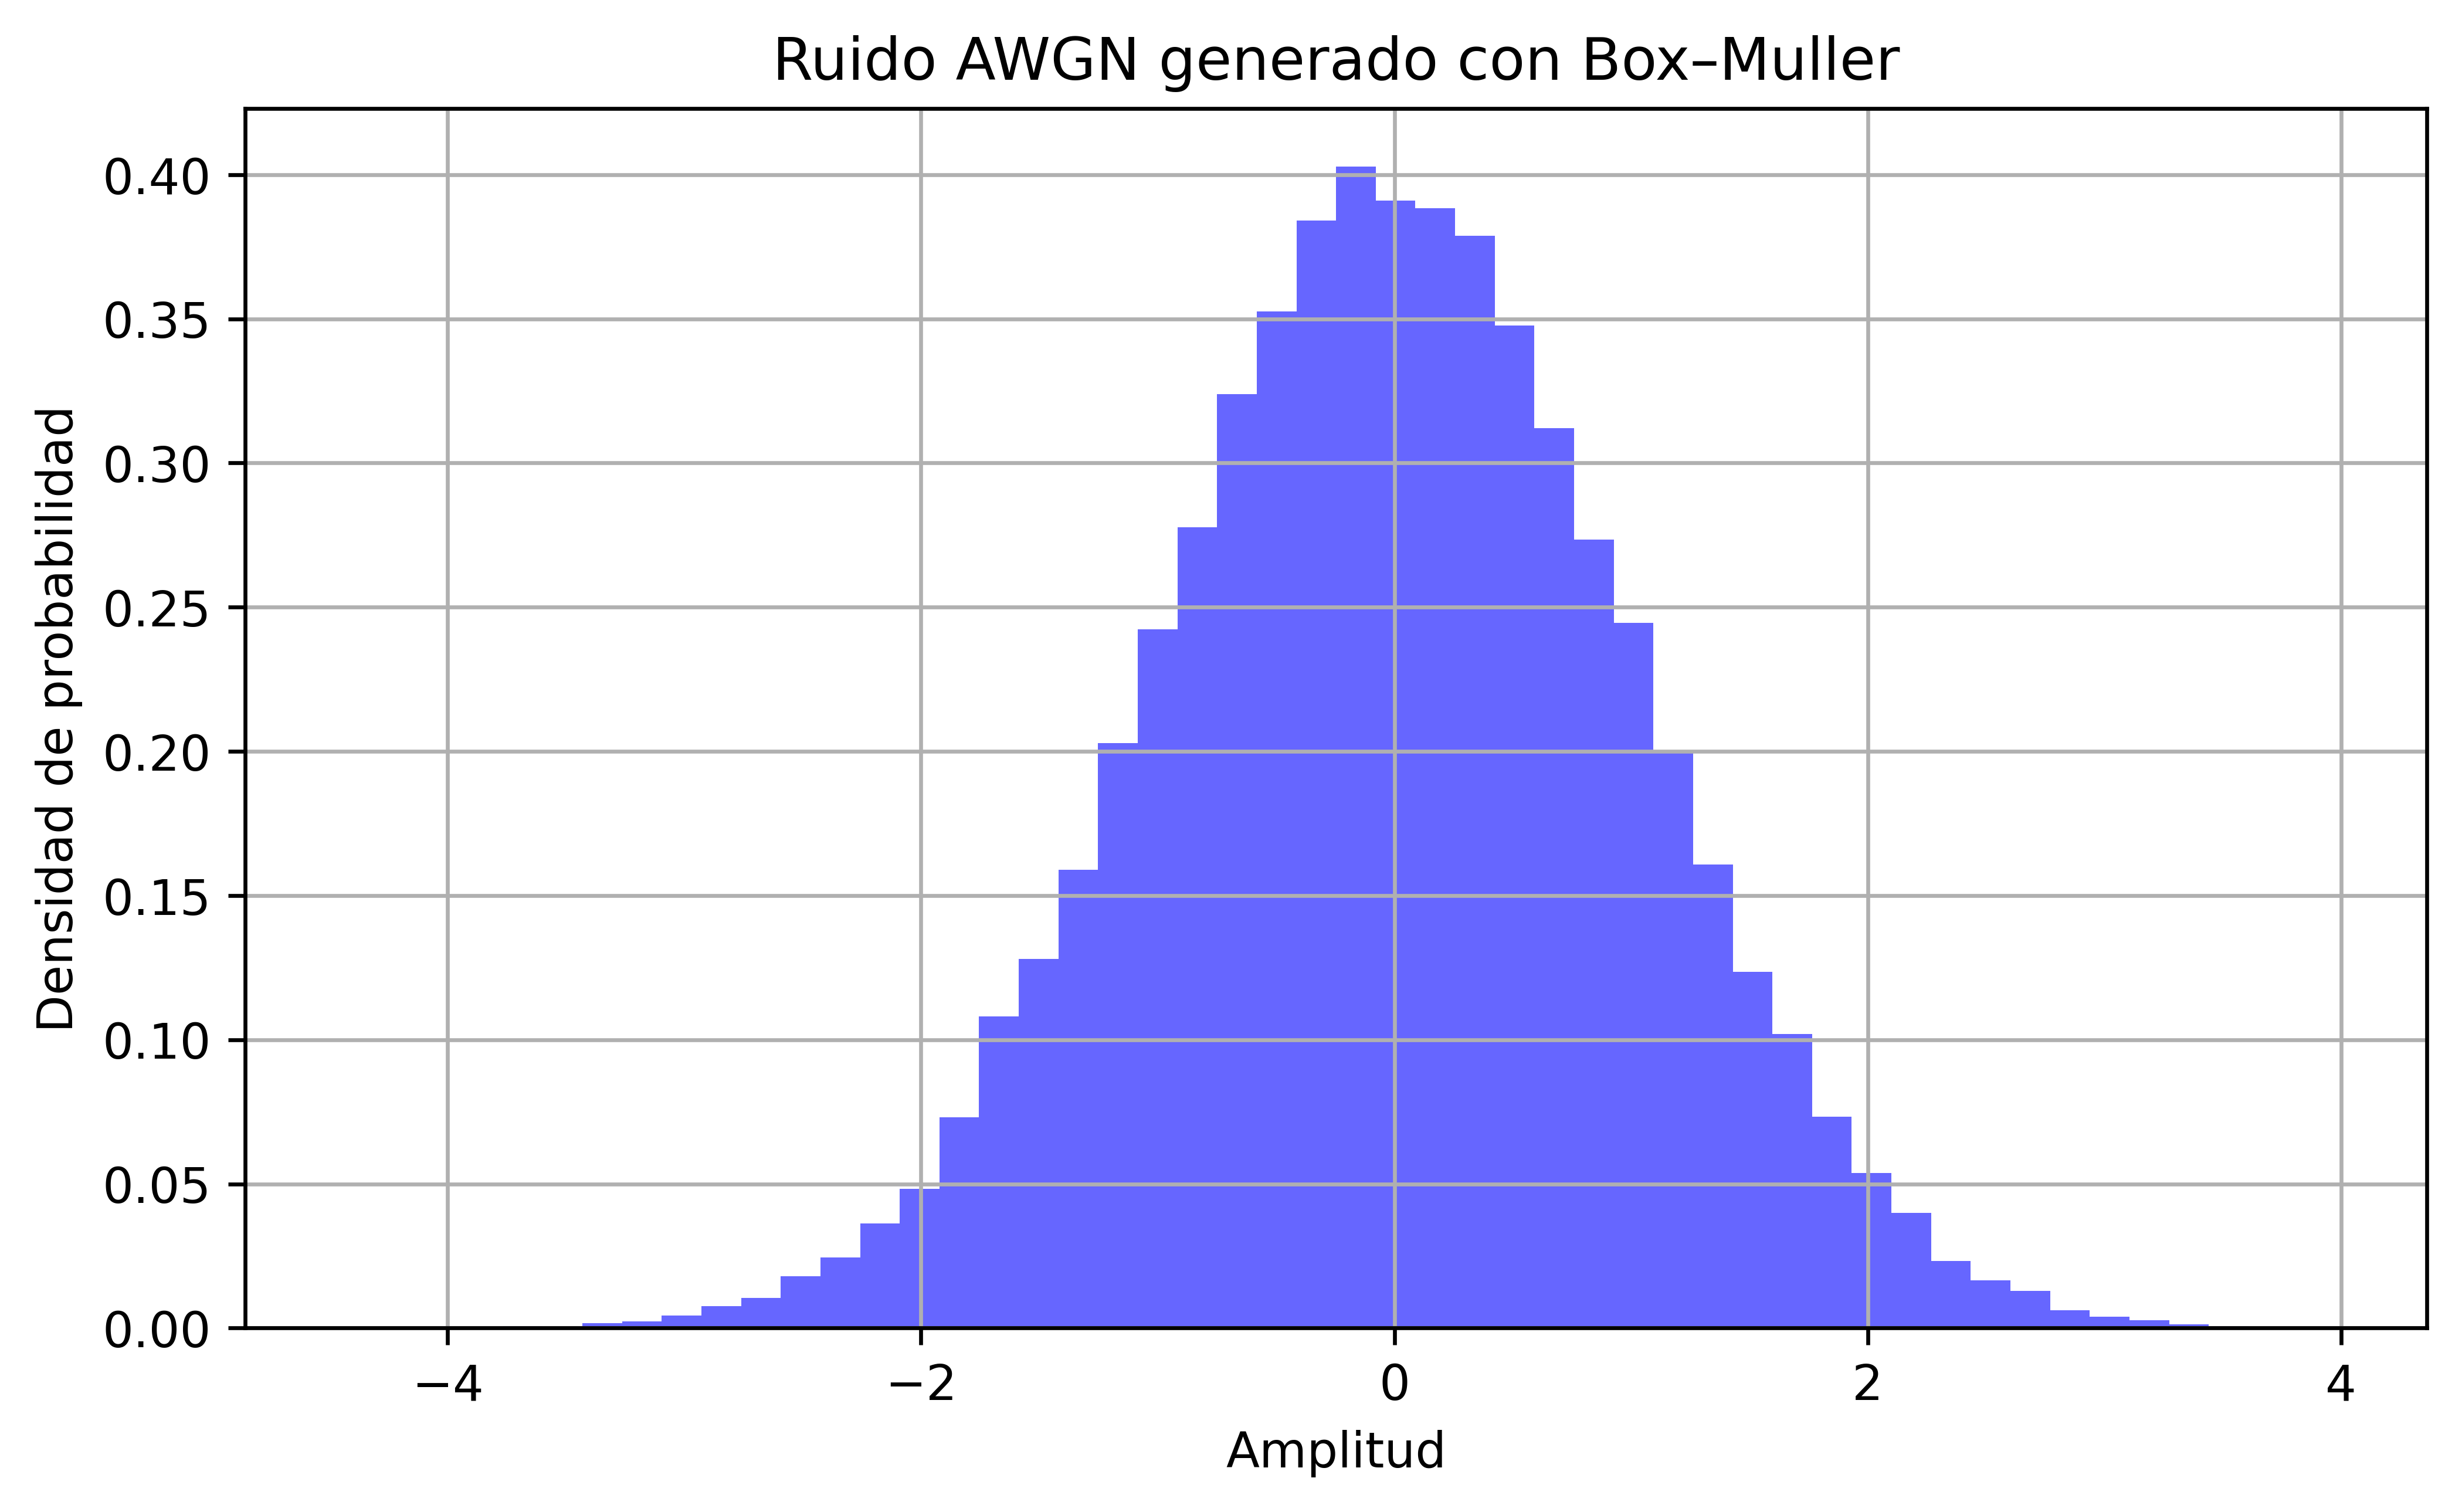

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros 
num_samples = 50000
np.random.seed(100)  # Semilla reproducible

# Box-Muller Transformation 
r1 = np.random.rand(num_samples)
r2 = np.random.rand(num_samples)

z = np.sqrt(-2 * np.log(r1)) * np.cos(2 * np.pi * r2)  # N(0,1)

#Escalamiento opciona
mu, sigma = 0, 1  # media y desviación estándar
awgn = mu + sigma * z

# === Histograma ===
plt.figure(dpi=600) 
plt.hist(awgn, bins=50, density=True, alpha=0.6, color='b')
plt.title("Ruido AWGN generado con Box–Muller")
plt.xlabel("Amplitud")
plt.ylabel("Densidad de probabilidad")
plt.grid(True)
plt.show()


Tras validar Box–Muller, se adopta Komm para el canal AWGN porque reduce complejidad, evita errores de escalado y facilita barridos de SNR/Eb/N0 con reproducibilidad controlada. En esta etapa se modela AWGN real (no I/Q), suficiente para los objetivos del proyecto.

In [4]:
import os
import numpy as np, komm

# ===== Mini test controlado de AWGN (Komm) con señal desde CSV =====
# Cargar señal GFSK exportada desde MATLAB: SistemaRF.ipynb/Matlab/csv/gfsk_signal.csv
csv_path = os.path.join("Matlab", "csv", "gfsk_signal.csv")
x = np.loadtxt(csv_path, delimiter=',', dtype=float)
x = np.asarray(x).astype(float).squeeze()

# Parámetros
snr_db  = 10.0                      # objetivo en dB
snr_lin = 10**(snr_db/10)           # Komm usa SNR lineal
seed    = 123

# Canal con potencia de señal "medida" y semilla reproducible
rng  = np.random.default_rng(seed)
awgn = komm.AWGNChannel(signal_power="measured", snr=snr_lin, rng=rng)

# Transmisión y mediciones
y = awgn.transmit(x)
n = y - x
Ps        = np.mean(x**2)           # potencia media de la señal A²/2
var_est   = np.var(n)               # varianza estimada del ruido
var_teo   = Ps / snr_lin            # varianza teórica Ps / SNR

print(f"Archivo: {csv_path}  |  N={len(x)}")
print(f"SNR(dB)={snr_db:.1f}  SNR(lineal)={snr_lin:.3f}")
print(f"Ps≈{Ps:.6f}  Var_teórica={var_teo:.6f}  Var_estimada={var_est:.6f}")
print(f"Error relativo={(abs(var_est-var_teo)/var_teo)*100:.2f}%")

# Reproducibilidad: misma semilla -> misma salida
rng2  = np.random.default_rng(seed)
awgn2 = komm.AWGNChannel(signal_power="measured", snr=snr_lin, rng=rng2)
y2    = awgn2.transmit(x)
print("Reproducible (misma seed):", np.allclose(y, y2))

# +3 dB debería ~reducir la varianza a la mitad
snr_db_plus3  = snr_db + 3.0
snr_lin_plus3 = 10**(snr_db_plus3/10)
rng3  = np.random.default_rng(seed)     # misma semilla para comparación limpia
awgn3 = komm.AWGNChannel(signal_power="measured", snr=snr_lin_plus3, rng=rng3)
y3    = awgn3.transmit(x)
n3    = y3 - x
var_est_plus3 = np.var(n3)
print(f"Varianza @ {snr_db:.1f} dB / varianza @ {snr_db_plus3:.1f} dB = {var_est/var_est_plus3:.2f} (≈2)")



Archivo: Matlab\csv\gfsk_signal.csv  |  N=139500
SNR(dB)=10.0  SNR(lineal)=10.000
Ps≈0.500102  Var_teórica=0.050010  Var_estimada=0.049973
Error relativo=0.07%
Reproducible (misma seed): True
Varianza @ 10.0 dB / varianza @ 13.0 dB = 2.00 (≈2)


In [6]:
#verificación de semilla distinta
y_a = komm.AWGNChannel(signal_power="measured", snr=snr_lin, rng=np.random.default_rng(123)).transmit(x)
y_b = komm.AWGNChannel(signal_power="measured", snr=snr_lin, rng=np.random.default_rng(124)).transmit(x)
print("Semilla distinta => salida distinta:", not np.allclose(y_a, y_b))


Semilla distinta => salida distinta: True
